In [1]:
# ── Install ───────────────────────────────────────────────────
!pip install scikit-learn -q

# ── Imports ───────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from scipy.spatial.distance import cdist
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# ── Device & Seeds ────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

# ── Config ────────────────────────────────────────────────────
IMG_SIZE  = 32
EMBED_DIM = 128
TOP_K     = 5

# ── Helper Functions ──────────────────────────────────────────
def retrieve(q_feat, gallery_feats, top_k=TOP_K):
    dists   = cdist(q_feat[np.newaxis], gallery_feats, metric='euclidean')[0]
    top_idx = np.argsort(dists)[:top_k]
    return top_idx, dists[top_idx]

def precision_at_k(ret_labels, q_label, k):
    return np.sum(ret_labels[:k] == q_label) / k

def recall_at_k(ret_labels, q_label, all_labels, k):
    total = np.sum(all_labels == q_label)
    return np.sum(ret_labels[:k] == q_label) / max(total, 1)

def average_precision(ret_labels, q_label):
    total = np.sum(ret_labels == q_label)
    if total == 0: return 0.0
    ap, n_rel = 0.0, 0
    for k, lbl in enumerate(ret_labels, 1):
        if lbl == q_label:
            n_rel += 1
            ap    += n_rel / k
    return ap / total

def evaluate(feats, labels, n_queries=100):
    q_idx = np.random.choice(len(feats), n_queries, replace=False)
    precs, recs, aps = [], [], []
    for qi in q_idx:
        mask = np.ones(len(feats), dtype=bool); mask[qi] = False
        idx, _ = retrieve(feats[qi], feats[mask])
        ret    = labels[mask][idx]
        precs.append(precision_at_k(ret, labels[qi], TOP_K))
        recs.append(recall_at_k(ret, labels[qi], labels[mask], TOP_K))
        aps.append(average_precision(ret, labels[qi]))
    return {f'Precision@{TOP_K}': np.mean(precs),
            f'Recall@{TOP_K}'   : np.mean(recs),
            'mAP'               : np.mean(aps)}

def to_display(img_tensor):
    img = img_tensor.permute(1,2,0).numpy()
    img = (img * 0.5) + 0.5
    return np.clip(img, 0, 1)

def show_retrieval(q_img, q_label, ret_imgs, ret_labels,
                   ret_dists, class_names, title, save_name):
    n   = len(ret_imgs) + 1
    fig, axes = plt.subplots(1, n, figsize=(2.8*n, 3.5))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    axes[0].imshow(q_img)
    axes[0].set_title(f'QUERY\n{class_names[q_label]}',
                      color='navy', fontweight='bold', fontsize=9)
    axes[0].axis('off')
    for i, (img, lbl, dist) in enumerate(zip(ret_imgs, ret_labels, ret_dists)):
        axes[i+1].imshow(img)
        ok = lbl == q_label
        axes[i+1].set_title(f'Rank {i+1} {"✓" if ok else "✗"}\n{class_names[lbl]}',
                             color='green' if ok else 'red', fontsize=9)
        axes[i+1].set_xlabel(f'dist={dist:.4f}', fontsize=8)
        axes[i+1].axis('off')
    plt.tight_layout()
    plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()

def plot_tsne(feats, labels, title, save_name):
    n      = min(500, len(feats))
    n_cls  = len(np.unique(labels[:n]))
    colors = plt.cm.tab10(np.linspace(0, 1, n_cls))
    proj   = TSNE(n_components=2, random_state=42,
                  perplexity=30).fit_transform(feats[:n])
    fig, ax = plt.subplots(figsize=(8, 7))
    for i, cls in enumerate(np.unique(labels[:n])):
        mask = labels[:n] == cls
        ax.scatter(proj[mask,0], proj[mask,1],
                   c=[colors[i % 10]], label=str(cls), s=15, alpha=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    ax.legend(title='Class', bbox_to_anchor=(1.01,1), fontsize=7, ncol=2)
    plt.tight_layout()
    plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()

def extract_embeddings(model, dataset, n_samples):
    model.eval()
    idx    = np.random.choice(len(dataset), n_samples, replace=False)
    loader = DataLoader(Subset(dataset, idx),
                        batch_size=256, shuffle=False, num_workers=2)
    feats, labels, imgs_list = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            _, emb = model(imgs.to(device))
            feats.append(emb.cpu().numpy())
            labels.append(lbls.numpy())
            imgs_list.append(imgs.cpu())
    return (np.concatenate(feats),
            np.concatenate(labels),
            torch.cat(imgs_list))

print(f'✅ Device  : {device}')
print(f'✅ All setup done!')

✅ Device  : cpu
✅ All setup done!


In [2]:
class CNN(nn.Module):
    """
    fi = CNN(Ii)

    Architecture:
    ┌─────────────────────────────────────────┐
    │  Input:  3 × 32 × 32                   │
    │  Block1: Conv(3→32) → BN → ReLU → Pool │  → 32×16×16
    │  Block2: Conv(32→64) → BN → ReLU → Pool│  → 64×8×8
    │  Block3: Conv(64→128) → BN → ReLU→ Pool│  → 128×4×4
    │  Flatten: 128×4×4 = 2048               │
    │  FC1: 2048 → 512 → ReLU → Dropout      │
    │  FC2: 512  → 128 (embedding)           │
    │  Classifier: 128 → n_classes           │
    └─────────────────────────────────────────┘

    Key advantage over NN/DNN:
    - Filters are translation invariant
    - Captures local spatial structure
    - Progressive feature hierarchy
    """
    def __init__(self, n_classes=10, embed_dim=128):
        super().__init__()

        # ── Convolutional Blocks ──────────────────────────────
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3×32×32 → 32×32×32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                           # → 32×16×16
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # → 64×16×16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                           # → 64×8×8
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# → 128×8×8
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                           # → 128×4×4
        )

        # ── Embedding Head ────────────────────────────────────
        self.encoder = nn.Sequential(
            nn.Flatten(),                  # 128×4×4 = 2048
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, embed_dim),     # → 128-dim embedding
            nn.ReLU()
        )

        self.classifier = nn.Linear(embed_dim, n_classes)

    def forward(self, x):
        x   = self.conv_block1(x)
        x   = self.conv_block2(x)
        x   = self.conv_block3(x)
        emb = self.encoder(x)
        out = self.classifier(emb)
        return out, emb    # logits for training, emb for retrieval

# ── Print architecture summary ────────────────────────────────
model_test   = CNN(n_classes=10)
total_params = sum(p.numel() for p in model_test.parameters())
print(model_test)
print(f'\n✅ CNN defined!')
print(f'   Total parameters : {total_params:,}')
print(f'   Embedding dim    : {EMBED_DIM}')

CNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, ou

In [3]:
# ── With augmentation for training (improves robustness) ──────
cifar_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),          # augmentation
    transforms.RandomCrop(32, padding=4),       # augmentation
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465],
                         [0.2023, 0.1994, 0.2010])  # CIFAR-10 exact stats
])

# ── Without augmentation for gallery/retrieval ────────────────
cifar_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465],
                         [0.2023, 0.1994, 0.2010])
])

cifar_train = datasets.CIFAR10('./data', train=True,
                                download=True,
                                transform=cifar_train_transform)
cifar_gallery = datasets.CIFAR10('./data', train=True,
                                  download=True,
                                  transform=cifar_test_transform)

cifar_class_names = ['airplane','automobile','bird','cat','deer',
                     'dog','frog','horse','ship','truck']

N_GALLERY_CIFAR = 2000

print(f'✅ CIFAR-10 loaded!')
print(f'   Train size   : {len(cifar_train)}')
print(f'   Gallery size : {N_GALLERY_CIFAR}')

100%|██████████| 170M/170M [00:03<00:00, 55.4MB/s]


✅ CIFAR-10 loaded!
   Train size   : 50000
   Gallery size : 2000


In [4]:
def train_cnn(model, dataset, n_epochs=15, lr=1e-3, model_name='CNN'):
    loader    = DataLoader(dataset, batch_size=128,
                           shuffle=True, num_workers=2)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.CrossEntropyLoss()
    history   = {'loss': [], 'acc': []}
    model.train()

    for epoch in range(n_epochs):
        total_loss, correct, total = 0.0, 0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits, _  = model(imgs)
            loss       = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
        scheduler.step()
        ep_loss = total_loss / total
        ep_acc  = correct / total
        history['loss'].append(ep_loss)
        history['acc'].append(ep_acc)
        print(f'  [{model_name}] Epoch {epoch+1:02d}/{n_epochs} '
              f'| Loss: {ep_loss:.4f} | Acc: {ep_acc:.4f}')

    print(f'\n✅ {model_name} training complete!')
    return history


print('🔁 Training CNN on CIFAR-10...')
cifar_cnn         = CNN(n_classes=10).to(device)
cifar_cnn_history = train_cnn(cifar_cnn, cifar_train,
                               n_epochs=15,
                               model_name='CIFAR-10 CNN')

🔁 Training CNN on CIFAR-10...
  [CIFAR-10 CNN] Epoch 01/15 | Loss: 1.4875 | Acc: 0.4470
  [CIFAR-10 CNN] Epoch 02/15 | Loss: 1.1435 | Acc: 0.5875
  [CIFAR-10 CNN] Epoch 03/15 | Loss: 1.0055 | Acc: 0.6423
  [CIFAR-10 CNN] Epoch 04/15 | Loss: 0.9247 | Acc: 0.6724
  [CIFAR-10 CNN] Epoch 05/15 | Loss: 0.8696 | Acc: 0.6955
  [CIFAR-10 CNN] Epoch 06/15 | Loss: 0.7693 | Acc: 0.7291
  [CIFAR-10 CNN] Epoch 07/15 | Loss: 0.7367 | Acc: 0.7417
  [CIFAR-10 CNN] Epoch 08/15 | Loss: 0.7161 | Acc: 0.7500
  [CIFAR-10 CNN] Epoch 09/15 | Loss: 0.6956 | Acc: 0.7568
  [CIFAR-10 CNN] Epoch 10/15 | Loss: 0.6767 | Acc: 0.7632
  [CIFAR-10 CNN] Epoch 11/15 | Loss: 0.6274 | Acc: 0.7807
  [CIFAR-10 CNN] Epoch 12/15 | Loss: 0.6097 | Acc: 0.7872
  [CIFAR-10 CNN] Epoch 13/15 | Loss: 0.6001 | Acc: 0.7904
  [CIFAR-10 CNN] Epoch 14/15 | Loss: 0.5910 | Acc: 0.7950
  [CIFAR-10 CNN] Epoch 15/15 | Loss: 0.5818 | Acc: 0.7956

✅ CIFAR-10 CNN training complete!


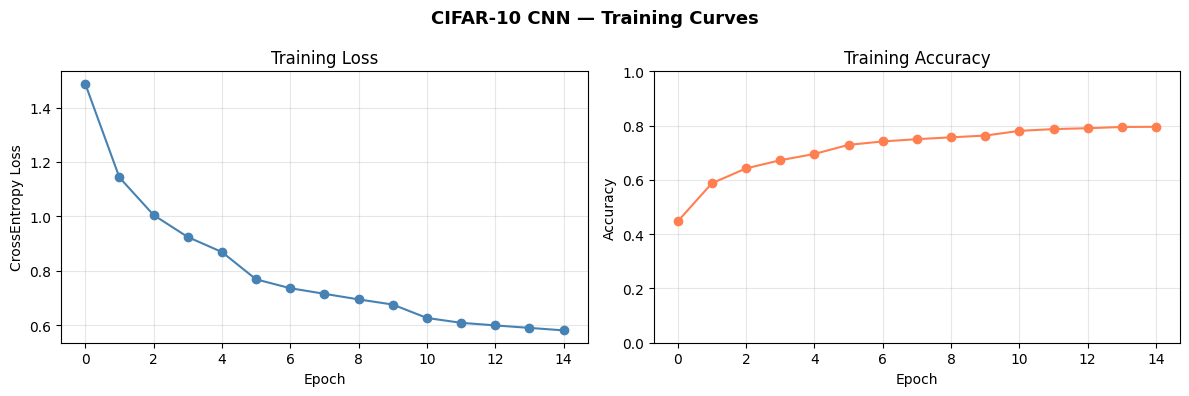

✅ Saved: cifar10_cnn_training.png → use in report


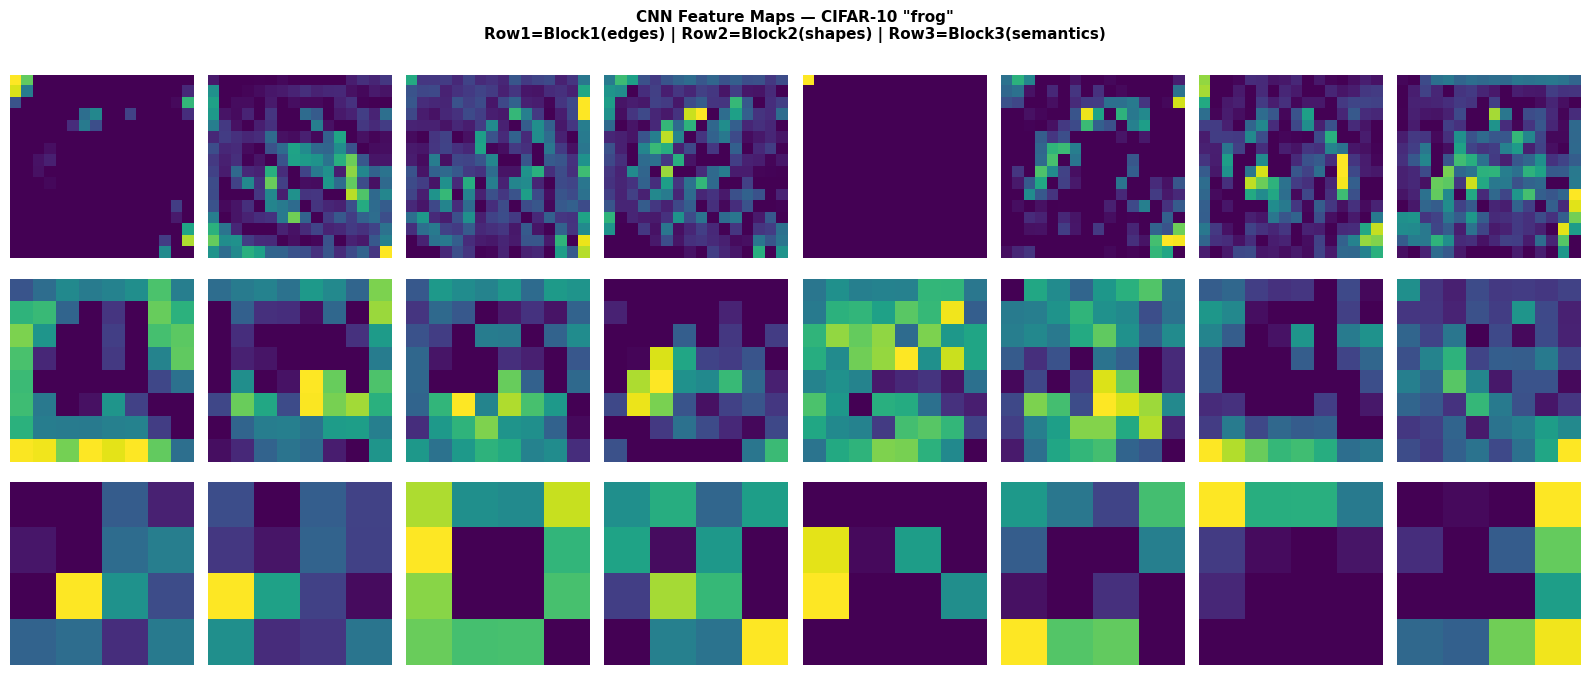

✅ Saved: cifar10_cnn_feature_maps.png → use in report (spatial learning analysis)


In [5]:
# ── Training curve ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CIFAR-10 CNN — Training Curves',
             fontsize=13, fontweight='bold')

axes[0].plot(cifar_cnn_history['loss'], marker='o', color='steelblue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CrossEntropy Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(cifar_cnn_history['acc'], marker='o', color='coral')
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cifar10_cnn_training.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: cifar10_cnn_training.png → use in report')

# ── Feature Map Visualisation ─────────────────────────────────
# Shows what conv layers are detecting
cifar_cnn.eval()
sample_img, sample_lbl = cifar_gallery[0]
inp = sample_img.unsqueeze(0).to(device)

with torch.no_grad():
    feat1 = cifar_cnn.conv_block1(inp)                        # after block1
    feat2 = cifar_cnn.conv_block2(feat1)                      # after block2
    feat3 = cifar_cnn.conv_block3(feat2)                      # after block3

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle(f'CNN Feature Maps — CIFAR-10 "{cifar_class_names[sample_lbl]}"\n'
             f'Row1=Block1(edges) | Row2=Block2(shapes) | Row3=Block3(semantics)',
             fontsize=11, fontweight='bold')

for row, (feat, block_name) in enumerate([
    (feat1, 'Block 1 — Edges & Colours'),
    (feat2, 'Block 2 — Shapes & Textures'),
    (feat3, 'Block 3 — Semantic Patterns')
]):
    for col in range(8):
        axes[row, col].imshow(feat[0, col].cpu().numpy(), cmap='viridis')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(block_name, fontsize=8, rotation=90,
                             labelpad=40)

plt.tight_layout()
plt.savefig('cifar10_cnn_feature_maps.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: cifar10_cnn_feature_maps.png → use in report (spatial learning analysis)')

Extracting CIFAR-10 CNN embeddings...
✅ CNN embeddings shape: (2000, 128)


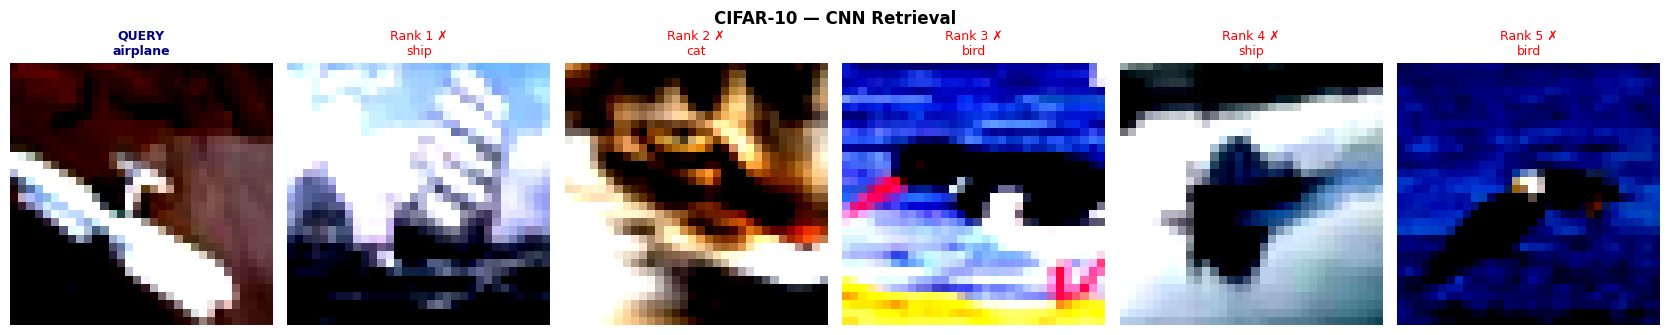

✅ Saved: cifar10_cnn_retrieval.png → use in report


In [6]:
print('Extracting CIFAR-10 CNN embeddings...')
cifar_cnn_feats, cifar_cnn_labels, cifar_cnn_imgs = \
    extract_embeddings(cifar_cnn, cifar_gallery, N_GALLERY_CIFAR)

print(f'✅ CNN embeddings shape: {cifar_cnn_feats.shape}')

# ── Retrieval demo ────────────────────────────────────────────
qi   = np.random.randint(0, N_GALLERY_CIFAR)
mask = np.ones(N_GALLERY_CIFAR, dtype=bool); mask[qi] = False

idx, dists = retrieve(cifar_cnn_feats[qi], cifar_cnn_feats[mask])
show_retrieval(
    q_img       = to_display(cifar_cnn_imgs[qi]),
    q_label     = cifar_cnn_labels[qi],
    ret_imgs    = [to_display(cifar_cnn_imgs[mask][i]) for i in idx],
    ret_labels  = cifar_cnn_labels[mask][idx],
    ret_dists   = dists,
    class_names = cifar_class_names,
    title       = 'CIFAR-10 — CNN Retrieval',
    save_name   = 'cifar10_cnn_retrieval.png'
)
print('✅ Saved: cifar10_cnn_retrieval.png → use in report')

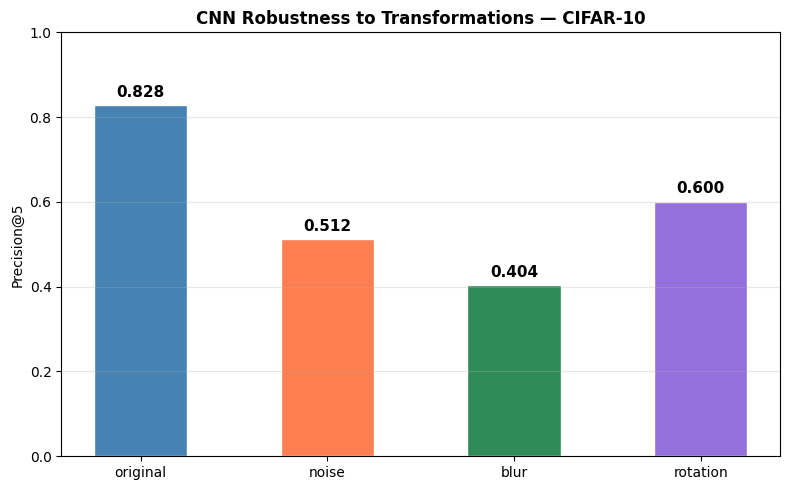

✅ Saved: cifar10_cnn_robustness.png → use in report (robustness analysis)


In [7]:
import torchvision.transforms.functional as TF

def apply_distortion(img_tensor, distortion_type):
    """Apply distortions to test CNN robustness."""
    img = img_tensor.clone()
    if distortion_type == 'noise':
        img = img + torch.randn_like(img) * 0.2
        img = torch.clamp(img, -1, 1)
    elif distortion_type == 'blur':
        img = TF.gaussian_blur(img, kernel_size=5)
    elif distortion_type == 'rotation':
        img = TF.rotate(img, angle=15)
    return img


distortions   = ['original', 'noise', 'blur', 'rotation']
n_test        = 50
robustness    = {d: [] for d in distortions}

test_idx = np.random.choice(N_GALLERY_CIFAR, n_test, replace=False)

for qi in test_idx:
    mask      = np.ones(N_GALLERY_CIFAR, dtype=bool); mask[qi] = False
    true_label = cifar_cnn_labels[qi]

    for dist in distortions:
        if dist == 'original':
            q_img = cifar_cnn_imgs[qi]
        else:
            q_img = apply_distortion(cifar_cnn_imgs[qi], dist)

        with torch.no_grad():
            _, q_emb = cifar_cnn(q_img.unsqueeze(0).to(device))
            q_feat   = q_emb.cpu().numpy()[0]

        idx, _ = retrieve(q_feat, cifar_cnn_feats[mask])
        ret_labels = cifar_cnn_labels[mask][idx]
        robustness[dist].append(precision_at_k(ret_labels, true_label, TOP_K))

# ── Plot robustness ───────────────────────────────────────────
mean_scores = [np.mean(robustness[d]) for d in distortions]
colors      = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(distortions, mean_scores, color=colors, edgecolor='white', width=0.5)
ax.set_title('CNN Robustness to Transformations — CIFAR-10',
             fontsize=12, fontweight='bold')
ax.set_ylabel(f'Precision@{TOP_K}')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for bar, score in zip(bars, mean_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('cifar10_cnn_robustness.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: cifar10_cnn_robustness.png → use in report (robustness analysis)')

📊 Evaluating CIFAR-10 CNN...

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
  CIFAR-10 CNN RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Precision@5    : 0.7920
  Recall@5       : 0.0200
  mAP            : 0.8387
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


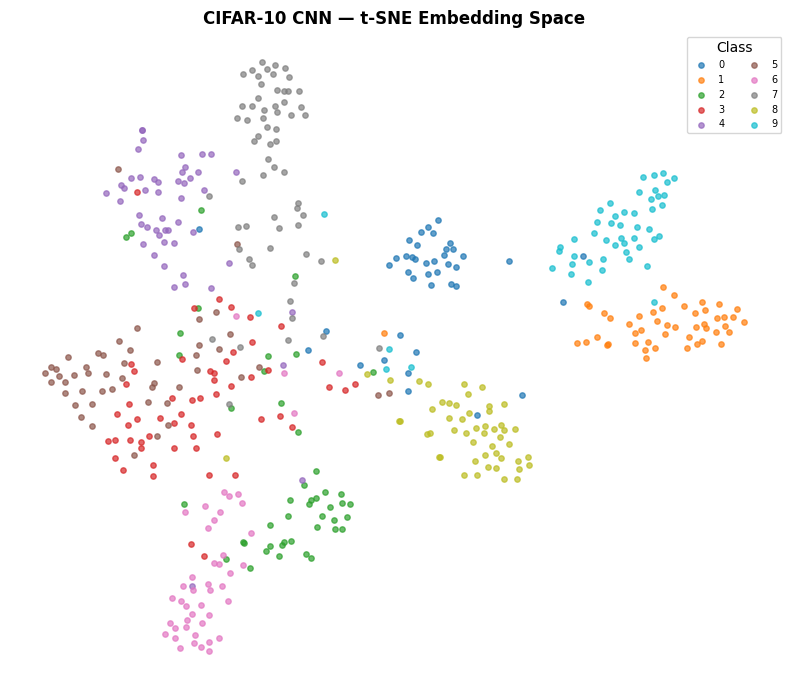

✅ Saved: tsne_cifar10_cnn.png → use in report

✅ CIFAR-10 CNN results saved!

📁 All files from this section:
   • cifar10_cnn_training.png            → Task 3 methodology
   • cifar10_cnn_feature_maps.png        → Task 3 spatial learning analysis
   • cifar10_cnn_retrieval.png           → Task 3 results
   • cifar10_cnn_robustness.png          → Task 3 robustness analysis
   • tsne_cifar10_cnn.png                → Task 3 embedding analysis


In [8]:
# ── Evaluate ──────────────────────────────────────────────────
print('📊 Evaluating CIFAR-10 CNN...')
cifar_cnn_metrics = evaluate(cifar_cnn_feats, cifar_cnn_labels)

print('\n━'*40)
print('  CIFAR-10 CNN RESULTS')
print('━'*40)
for metric, val in cifar_cnn_metrics.items():
    print(f'  {metric:<15}: {val:.4f}')
print('━'*40)

# ── t-SNE ─────────────────────────────────────────────────────
plot_tsne(cifar_cnn_feats, cifar_cnn_labels,
          title    = 'CIFAR-10 CNN — t-SNE Embedding Space',
          save_name= 'tsne_cifar10_cnn.png')
print('✅ Saved: tsne_cifar10_cnn.png → use in report')

# ── Save to ALL_RESULTS ───────────────────────────────────────
if 'ALL_RESULTS' not in dir():
    ALL_RESULTS = {}
if 'CIFAR-10' not in ALL_RESULTS:
    ALL_RESULTS['CIFAR-10'] = {}

ALL_RESULTS['CIFAR-10']['CNN'] = {
    'Precision@5' : cifar_cnn_metrics[f'Precision@{TOP_K}'],
    'Recall@5'    : cifar_cnn_metrics[f'Recall@{TOP_K}'],
    'mAP'         : cifar_cnn_metrics['mAP'],
    'Remarks'     : 'Spatial learning — significant improvement over NN/DNN'
}

print('\n✅ CIFAR-10 CNN results saved!')
print('\n📁 All files from this section:')
files = [
    ('cifar10_cnn_training.png',     '→ Task 3 methodology'),
    ('cifar10_cnn_feature_maps.png', '→ Task 3 spatial learning analysis'),
    ('cifar10_cnn_retrieval.png',    '→ Task 3 results'),
    ('cifar10_cnn_robustness.png',   '→ Task 3 robustness analysis'),
    ('tsne_cifar10_cnn.png',         '→ Task 3 embedding analysis'),
]
for fname, note in files:
    print(f'   • {fname:<35} {note}')